# COMP219
## Lab 8 - ROC and PRC
In this week's lab, we will cover two model evaluation techniques: receiver operating characteristics (ROC) and precision recall (PR) curves. Both of these evaluation techniques are visual representation of the model's performance. We covered various other evaluation techniques previously, see
- Lab 3: Confusion matrix, accuracy, precision, recall, F1-score
- Lab 5: RMSE, MAE, R²

You can find the Python script for these tests on Xiaowei's [GitHub](https://github.com/xiaoweih/AISafetyLectureNotes/tree/main/Part_1).

### Introduction to ROC
ROC shows the difference between the true positive rate (TPR, or sensitivity) and the false positive rate (FPR, or specificity) at various classification thresholds. The TPR and FPR are calculated using these formulas:
$$
TPR = \frac{TP}{TP + FN}
$$

$$
FPR = \frac{FP}{FP + TN}
$$


    Where:

- $ TP $ is the number of true positives
- $ FN $ is the number of false negatives
- $ FP $ is the number of false positives
- $ TN $ is the number of false negatives.

When plotting the ROC, we put FPR on the x-axis and TPR on the y-axis (both ranging from 0 to 1). Each point on the curve corresponds to a specific threshold used to classify data as either positive or negative. The plot shows two lines: a diagonal straight line (the baseline) and a line above the diagonal (model performance). The closer the curve is to the top-left corner, the better the model performs (e.g. TPR = 1, FPR = 0).

#### Area Under The Curve (AUC)
The AUC-ROC is derived from the ROC curve. This metric measures the model's overall performance on classification problems. The AUC is computed as the integral of TPR with respect to FPR:

$$
AUC = \int_0^1 \text{TPR} \, d(\text{FPR})
$$

The following is the interpretation of the value of the integral:
- AUC = 1: the model is perfect
- AUC = 0.5: the model performs no better than random guessing
- AUC < 0.5: the model performs worse than random guessing.

The code below is set to import one of two datasets: iris and breast cancer. By default, iris is loaded, if you would like to change to a different dataset, comment out line 15 and uncomment line 16 to load the breast cancer dataset. In this example, we add some random noise to the data and we use a support vector machine (SVM) classifier.

We won't cover SVMs in this lab as we are focusing only on evaluation. However, if you would like to read into the topic, here is an excellent [TDS article](https://towardsdatascience.com/support-vector-machine-introduction-to-machine-learning-algorithms-934a444fca47) which provides both theory and implementation.

[[0 0 1]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [1 0 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [0 0 1]
 [1 0 0]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [0 0 1]
 [1 0 0]
 [1 0 0]
 [0 1 0]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [0 1 0]]


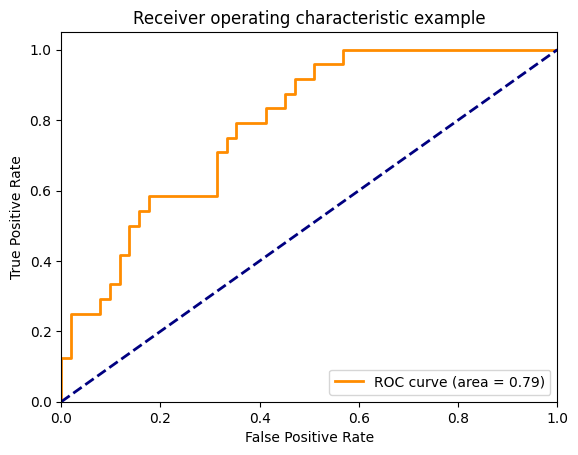

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from scipy.interpolate import interp1d
from sklearn.metrics import roc_auc_score

# Import some data to play with

dataset = datasets.load_iris()
#dataset = datasets.load_breast_cancer()
X = dataset.data
y = dataset.target

# Binarize the output
y = label_binarize(y, classes=[0, 1, 2])
n_classes = y.shape[1]

# Add noisy features to make the problem harder
random_state = np.random.RandomState(0)
n_samples, n_features = X.shape
X = np.c_[X, random_state.randn(n_samples, 200 * n_features)]

# shuffle and split training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.5,
                                                    random_state=0)

# Learn to predict each class against the other
classifier = OneVsRestClassifier(svm.SVC(kernel='linear', probability=True,
                                 random_state=random_state))
y_score = classifier.fit(X_train, y_train).decision_function(X_test)

print(y_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
#micro-avg is an aggregate performance across multiple classes
#we treat all class predictions as a single set of binary decisions
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
lw = 2
plt.plot(fpr[2], tpr[2], color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

### Introduction to PRC
PRC is another visual representation of model performance. It shows the difference between precision and recall for different classification thresholds. The key metrics are recall (x-axis) and precision (y-axis) , defined by the following formulas:

$$
Recall = \frac{\text{TP}}{\text{TP} + \text{FN}}
$$

$$
Precision = \frac{\text{TP}}{\text{TP} + \text{FP}}
$$

Note: recall is the same as TPR.

Each point corresponds to a specific decision threshold used for classification. A perfect model would have a PRC reaching the top-right corner of the plot (recall = 1, precision = 1).

PRC is useful when the dataset has a large class imbalance (for example, one class may be overrepresented in the dataset).

The code below implements PRC.

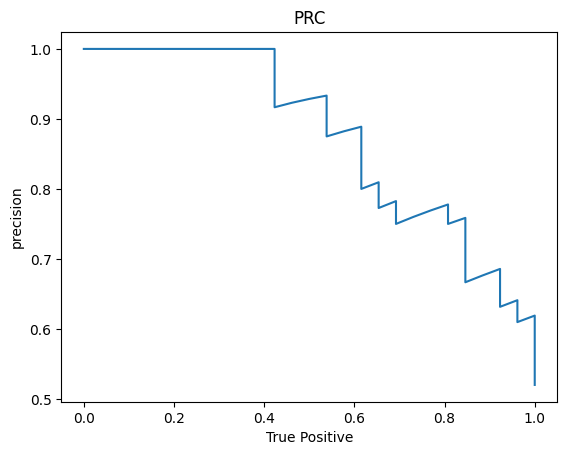

In [2]:
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import (precision_recall_curve, PrecisionRecallDisplay)
import matplotlib.pyplot as plt

iris = datasets.load_iris()
X = iris.data
y = iris.target

# Add noisy features
random_state = np.random.RandomState(0)
n_samples, n_features = X.shape
X = np.c_[X, random_state.randn(n_samples, 200 * n_features)]

# Limit to the two first classes, and split into training and test
X_train, X_test, y_train, y_test = train_test_split(X[y < 2], y[y < 2],
                                                    test_size=.5,
                                                    random_state=random_state)

# Create a simple classifier
classifier = svm.LinearSVC(random_state=random_state)
classifier.fit(X_train, y_train)
y_score = classifier.decision_function(X_test)

precision, recall, _ = precision_recall_curve(y_test, y_score)

plt.plot(recall, precision)
plt.title('PRC')
plt.xlabel('True Positive')
plt.ylabel('precision')

plt.show()

Chapter 2 of the book Machine Learning Safety describes all the evaluation techniques we have covered.